# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [1]:
import pandas as pd

data = pd.read_csv('delivery_dataset.csv')
data

,Дата заказа (ГГГГ-ММ-ДД),Шифр заказа (ID),Расстояние до клиента (в км),Количество позиций в чеке (в шт.),Балл пробок на дорогах (в баллах),Погода (в градусах Цельсия),Этаж доставки (в этажах),Время доставки (в минутах)
0,2026-09-08,ORD-202608001,11.3,1,9,21.0,6,79.2
1,2026-08-29,ORD-202608002,7.3,3,7,27.0,7,46.6
2,2026-08-15,ORD-202608003,2.2,1,3,20.0,5,16.3
3,2026-08-08,ORD-202608004,0.9,2,6,22.9,1,15.8
4,2026-08-21,ORD-202608005,12.3,14,4,18.1,2,69.2
...,...,...,...,...,...,...,...,...
495,2026-08-12,ORD-202608496,5.2,2,3,18.0,9,28.9
496,2026-08-09,ORD-202608497,10.0,3,4,21.6,10,48.0
497,2026-08-07,ORD-202608498,5.5,3,2,9.5,3,27.0
498,2026-08-28,ORD-202608499,7.1,6,4,13.5,1,40.4


#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [2]:
feature_cols = ['Расстояние до клиента (в км)', 'Количество позиций в чеке (в шт.)', 'Балл пробок на дорогах (в баллах)', 'Погода (в градусах Цельсия)', 'Этаж доставки (в этажах)']
target_col = 'Время доставки (в минутах)'

train_data = data.iloc[:300]
val_data = data.iloc[300:400]
test_data = data.iloc[400:500]

X_train, y_train = train_data[feature_cols].values, train_data[target_col].values
X_val, y_val = val_data[feature_cols].values, val_data[target_col].values
X_test, y_test = test_data[feature_cols].values, test_data[target_col].values

print('Train: ', X_train.shape, y_train.shape)
print('Val: ', X_val.shape, y_val.shape)
print('Test: ', X_test.shape, y_test.shape)

Train:  (300, 5) (300,)
Val:  (100, 5) (100,)
Test:  (100, 5) (100,)


#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [3]:
!pip install scikit-learn

#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [4]:
import numpy as np
from sklearn.linear_model import Ridge

model = Ridge(alpha=0.0, solver='sparse_cg')
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
sse_train = np.sum((y_train - y_train_pred) ** 2)

print('Веса (w1..w4):', model.coef_)
print('Свободный член (w0):', model.intercept_)
print(f'SSE на тренировочной выборке: {sse_train:.3f}')

Веса (w1..w4): [ 4.39612671  0.83532692  2.15389382 -0.04734781  0.34323145]
Свободный член (w0): -2.9673282180037432
SSE на тренировочной выборке: 5529.134


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

Обучение остановилось на итерации 7 (норма невязки = 0.000000)
Веса, полученные вручную (w0, w1..w4): [-2.96732822  4.39612671  0.83532692  2.15389382 -0.04734781  0.34323145]
Веса из sklearn Ridge:                 [-2.96732822  4.39612671  0.83532692  2.15389382 -0.04734781  0.34323145]


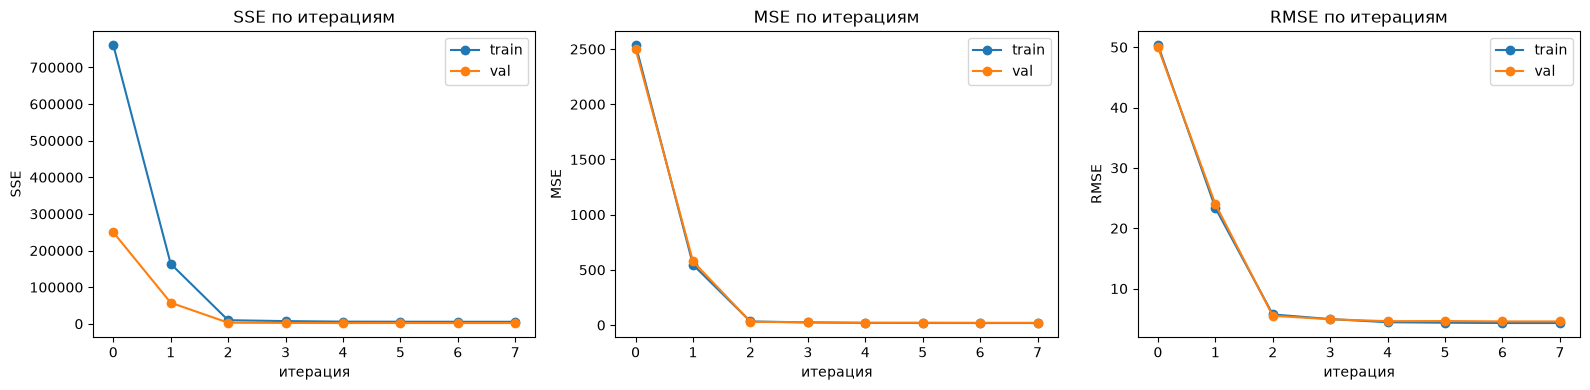

Для сравнения: Время доставки (в минутах) = 42.13, std price = 26.50


In [ ]:
import matplotlib.pyplot as plt

def add_bias(X):
    return np.hstack([np.ones((X.shape[0], 1)), X])

X_train_b = add_bias(X_train)
X_val_b = add_bias(X_val)

A = X_train_b.T @ X_train_b
b = X_train_b.T @ y_train

def compute_errors(X, y, w):
    residuals = y - X @ w
    sse = np.sum(residuals ** 2)
    mse = sse / len(y)
    rmse = np.sqrt(mse)
    return sse, mse, rmse

eps = 1e-3
max_iter = 1000

w = np.zeros(X_train_b.shape[1])
r = b - A @ w
p = r.copy()

sse_train_hist, mse_train_hist, rmse_train_hist = [], [], []
sse_val_hist, mse_val_hist, rmse_val_hist = [], [], []

for k in range(max_iter):
    sse_t, mse_t, rmse_t = compute_errors(X_train_b, y_train, w)
    sse_v, mse_v, rmse_v = compute_errors(X_val_b, y_val, w)
    sse_train_hist.append(sse_t); mse_train_hist.append(mse_t); rmse_train_hist.append(rmse_t)
    sse_val_hist.append(sse_v); mse_val_hist.append(mse_v); rmse_val_hist.append(rmse_v)

    if np.linalg.norm(r) < eps:
        break

    Ap = A @ p
    alpha = (r @ r) / (p @ Ap)
    w = w + alpha * p
    r_new = r - alpha * Ap
    beta = (r_new @ r_new) / (r @ r)
    p = r_new + beta * p
    r = r_new

print(f'Обучение остановилось на итерации {len(sse_train_hist) - 1} (норма невязки = {np.linalg.norm(r):.6f})')
print('Веса, полученные вручную (w0, w1..w4):', w)
print('Веса из sklearn Ridge: ', np.r_[model.intercept_, model.coef_])

iters = range(len(sse_train_hist))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(iters, sse_train_hist, marker='o', label='train')
axes[0].plot(iters, sse_val_hist, marker='o', label='val')
axes[0].set_title('SSE по итерациям'); axes[0].set_xlabel('итерация'); axes[0].set_ylabel('SSE'); axes[0].legend()

axes[1].plot(iters, mse_train_hist, marker='o', label='train')
axes[1].plot(iters, mse_val_hist, marker='o', label='val')
axes[1].set_title('MSE по итерациям'); axes[1].set_xlabel('итерация'); axes[1].set_ylabel('MSE'); axes[1].legend()

axes[2].plot(iters, rmse_train_hist, marker='o', label='train')
axes[2].plot(iters, rmse_val_hist, marker='o', label='val')
axes[2].set_title('RMSE по итерациям'); axes[2].set_xlabel('итерация'); axes[2].set_ylabel('RMSE'); axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Для сравнения: Время доставки (в минутах) = {data['Время доставки (в минутах)'].mean():.2f}, std price = {data['Время доставки (в минутах)'].std():.2f}")

#### Шаг 6. Применение модели на тестовой выборке

In [7]:
y_test_pred = model.predict(X_test)

results = pd.DataFrame({
    'Шифр заказа (ID)': test_data['Шифр заказа (ID)'].values,
    'predicted_time': y_test_pred,
    'true_time': y_test,
    'difference': y_test_pred - y_test,
})

results.to_csv('test_predictions_orders.csv', index=False)
results

,Шифр заказа (ID),predicted_time,true_time,difference
0,ORD-202608401,33.066235,33.9,-0.833765
1,ORD-202608402,33.125508,33.1,0.025508
2,ORD-202608403,20.852183,16.3,4.552183
3,ORD-202608404,34.385205,34.7,-0.314795
4,ORD-202608405,17.562288,13.3,4.262288
...,...,...,...,...
95,ORD-202608496,30.261688,28.9,1.361688
96,ORD-202608497,54.525097,48.0,6.525097
97,ORD-202608498,28.605027,27.0,1.605027
98,ORD-202608499,41.576744,40.4,1.176744


#### Шаг 7. RMSE на тестовой выборке

In [8]:
sse_test = np.sum((y_test - y_test_pred) ** 2)
mse_test = sse_test / len(y_test)
rmse_test = np.sqrt(mse_test)

print(f'SSE на тестовой выборке: {sse_test:.3f}')
print(f'MSE на тестовой выборке: {mse_test:.3f}')
print(f'RMSE на тестовой выборке: {rmse_test:.3f}')

SSE на тестовой выборке: 2333.984
MSE на тестовой выборке: 23.340
RMSE на тестовой выборке: 4.831


Вопрос 1:
Данные делят на выборки, чтобы оценить качество модели, а не проверить, запомнила ли она ответы. Тренировочная выборка нужна для обучения модели. Валидационная, чтобы во время подбора модели отслеживать её качество на новых данных и вовремя заметить переобучение. Тестовая используется один раз в самом конце и даёт итоговую объективную оценку, поскольку модель её никогда не видела и под неё не подстраивалась.

Вопрос 2
Эти графики показывают, как ошибка модели (SSE, MSE, RMSE) меняется по мере обучения, то есть насколько быстро и до какого уровня модель сходится к оптимальным весам. Сравнение линий train и val на одном графике позволяет определить качество обучения: если обе ошибки падают и выходят на низкий уровень, то модель обучилась хорошо; если ошибка на train продолжает падать, а на val начинает расти, значит модель переобучилась если обе ошибки остаются высокими и не снижаются — модель недообучилась.

Вопрос 3
Недообученная модель: обе линии train и val остаются высокими и почти не снижаются, идут близко друг к другу на высоком уровне. модели не хватает сложности, чтобы уловить закономерность даже в тренировочных данных.

Обученная модель: обе линии падают и выходят на низкий уровень, идут близко друг к другу. модель одинаково хорошо работает и на train, и на новых val данных.

Переобученная модель: линия train продолжает падать, а линия val с какого-то момента начинает расти. модель подстроилась под шум тренировочных данных и хуже обобщает на новые.

Вопрос 4
RMSE ≈ 4.83 минуты означает, что в среднем предсказанное время доставки отличается от настоящего примерно на 4.83 минуты. При среднем времени доставки 42 мин и разбросе 26.5 мин это небольшая ошибка. модель предсказывает достаточно точно, значит она хорошо обучена, а не недообучена или переобучена.